# Финальный проект: Телекоммуникации

**Описание исследования:**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи.

Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. 

*Описание услуг:*

Оператор предоставляет два основных типа услуг: 

- Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.

- Интернет. Подключение может быть двух типов: через телефонную линию (`DSL`, от англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (`Fiber optic`).

Также доступны такие услуги:

- Интернет-безопасность: антивирус (`DeviceProtection`) и блокировка небезопасных сайтов (`OnlineSecurity`);

- Выделенная линия технической поддержки (`TechSupport`);

- Облачное хранилище файлов для резервного копирования данных (`OnlineBackup`);

- Стриминговое телевидение (`StreamingTV`) и каталог фильмов (`StreamingMovies`).

Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.

**Цель исследования:**

Обучить на предоставленных заказчиком данных модель, которая будет прогнозировать отток клиентов.

**Задачи исследования:**

1. Загрузка, чтение, предобработка данных.
2. Объединение данных, создание новых признаков.
3. Исследовательский анализ данных.
4. Построение матрицы корреляции.
5. Подготовка данных.Обучение моделей машинного обучения. Выбор лучшей модели.
6. Предсказание выбранной модели на тестовых данных. Общие выводы.

**Исходные данные:**

Данные состоят из нескольких файлов, полученных из разных источников:

1. `contract_new.csv` — информация о договоре:

    * customerID — идентификатор абонента;
    
    * BeginDate — дата начала действия договора;
    
    * EndDate — дата окончания действия договора;
    
    * Type — тип оплаты: раз в год-два или ежемесячно;
    
    * PaperlessBilling — электронный расчётный лист;
    
    * PaymentMethod — тип платежа;
    
    * MonthlyCharges — расходы за месяц;
    
    * TotalCharges — общие расходы абонента.
    
    
2. `personal_new.csv` — персональные данные клиента:

   * customerID — идентификатор пользователя;
    
   * gender — пол;
    
   * SeniorCitizen — является ли абонент пенсионером;
    
   * Partner — есть ли у абонента супруг или супруга;
   
   * Dependents — есть ли у абонента дети.
   

3. `internet_new.csv` — информация об интернет-услугах:

    * customerID — идентификатор пользователя;

    * InternetService — тип подключения;

    * OnlineSecurity — блокировка опасных сайтов;

    * OnlineBackup — облачное хранилище файлов для резервного копирования данных;

    * DeviceProtection — антивирус;

    * TechSupport — выделенная линия технической поддержки;

    * StreamingTV — стриминговое телевидение;

    * StreamingMovies — каталог фильмов.
    
    
4. `phone_new.csv`— информация об услугах телефонии:

    * customerID — идентификатор пользователя;
    
    * MultipleLines — подключение телефона к нескольким линиям одновременно.
    
    
Во всех файлах столбец `customerID` содержит код клиента. Информация о договорах актуальна на **1 февраля 2020 года**.


# Импорт необходимых библиотек и констант

In [1]:
# Обновим и установим библиотеки, которые пригодятся в исследовании:
!pip install -U -q scikit-learn
!pip install -q phik

In [2]:
# Импорт библиотек, моделей, метрик для исследования

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix


from sklearn.model_selection import (train_test_split,
                                    RandomizedSearchCV
                                    )
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score,
                            f1_score,
                            accuracy_score,
                            recall_score,
                            precision_score,
                            roc_curve)
from sklearn.preprocessing import (OneHotEncoder,
                                   OrdinalEncoder,
                                   StandardScaler,
                                   MinMaxScaler,
                                   LabelEncoder,
                                   RobustScaler
                                  )
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from catboost import (Pool,
                      CatBoostClassifier
                     )


import warnings
warnings.filterwarnings('ignore')


# Импорт констант
test_size = 0.25 
RANDOM_STATE = 10022025 # Дата начала финального спринта

In [3]:
# Оределим необходимые функции:

# Функция для вывода информации о датасете:
def info(df: pd.DataFrame, name: str = 'DataFrame'):
   
    print(f'Информация о датасете {name}')
    print()
    print(f'Семь случайных строк датасета {name}')
    display(df.sample(7))
    print()
    print(f'Информация о {name}')
    print()
    display(df.info())
    print()
    print(f'Описательная статистика датасета {name}')
    print()
    display(df.describe())

# Функция для приведения названия столбцов к snake_case

def rename_func(df):
    df.columns = (df.columns
                  .str.replace(' ', '_') 
                  .str.replace(r'([a-z])([A-Z])', r'\1_\2')  
                  .str.lower()) 
      
        
# Функция для выявления уникальных значений категориальных столбцов
def unique_values(dataframes):
    for df in dataframes:
        for column in df.select_dtypes(include=['object']).columns:
            print(f'Уникальные значения для {column}:')
            print(df[column].unique())
            print()

In [4]:
# Чтение датасетов:

# contract_new 
try:
    contract_new = pd.read_csv('/datasets/contract_new.csv', parse_dates={'begin_date': ['BeginDate']})
except:
    contract_new = pd.read_csv('https://code.s3.yandex.net/datasets/contract_new.csv', parse_dates={'date': ['BeginDate']})

    
#personal_new  
try:
    personal_new = pd.read_csv('/datasets/personal_new.csv')
except:
    personal_new = pd.read_csv('https://code.s3.yandex.net/datasets/personal_new.csv')    
    
# internet_new
try:
    internet_new = pd.read_csv('/datasets/internet_new.csv')
except:
    internet_new = pd.read_csv('https://code.s3.yandex.net/datasets/internet_new.csv')
    
# phone_new
try:
    phone_new = pd.read_csv('/datasets/phone_new.csv')
except:
    phone_new = pd.read_csv('https://code.s3.yandex.net/datasets/phone_new.csv')
       

In [5]:
dataframes = [contract_new, personal_new, internet_new, phone_new]

## Загрузка, чтение, предобработка данных

### Датасет contract_new

In [6]:
info(contract_new, name='contract_new')

Информация о датасете contract_new

Семь случайных строк датасета contract_new


,begin_date,customerID,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5873,2018-08-01,2122-YWVYA,No,Month-to-month,Yes,Electronic check,75.40,1357.2
1878,2019-11-01,0463-WZZKO,No,Month-to-month,Yes,Credit card (automatic),20.75,62.25
6238,2015-08-01,5188-HGMLP,No,Month-to-month,No,Bank transfer (automatic),74.00,4035.96
7003,2017-12-01,4501-VCPFK,2019-04-01,Month-to-month,No,Electronic check,35.75,572.0
396,2017-05-01,0177-PXBAT,No,Month-to-month,Yes,Bank transfer (automatic),109.90,3844.3
633,2019-04-01,7665-VIGUD,No,One year,No,Mailed check,20.35,203.5
359,2016-08-01,9833-TGFHX,No,One year,No,Electronic check,97.10,4241.33



Информация о contract_new

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   begin_date        7043 non-null   datetime64[ns]
 1   customerID        7043 non-null   object        
 2   EndDate           7043 non-null   object        
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 440.3+ KB


None


Описательная статистика датасета contract_new



,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


**Предварительный вывод, сделанный на основании информации, полученной о датасете contract_new**

Датасет содержит 7043 записи, пропуски отсутствуют, сразу бросаются названия столбцов, которые не соответствуют змеиному регистру (snake_case) и требуют переименования.

Также можно отметить неверный тип данных у столбцов:
BeginDate, EndDate (должен быть datetime)
TotalCharges должен быть float, так как содержит в себе данные чисел с плавающей запятой, как и в столбце MonthlyCharges. Но скорее всего, этот тип данных определился, т.к. в столбце есть Nan значения. Проверим далее это предположение.


In [7]:
rename_func(contract_new) # приведем названия столбцов к snake_case
contract_new.head()

,begin_date,customer_id,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,2020-01-01,7590-VHVEG,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,2017-04-01,5575-GNVDE,No,One year,No,Mailed check,56.95,2071.84
2,2019-10-01,3668-QPYBK,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,2016-05-01,7795-CFOCW,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,2019-09-01,9237-HQITU,No,Month-to-month,Yes,Electronic check,70.70,353.5


In [8]:
contract_new['total_charges'] = pd.to_numeric(contract_new['total_charges'], errors='coerce') 
# Изменили тип данных столбца а также заполнили ошибочные значения в столбце на Nan

In [9]:
contract_new.info()
# Просмотрим сведения о датасете

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[ns]
 1   customer_id        7043 non-null   object        
 2   end_date           7043 non-null   object        
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 440.3+ KB


В результате изменения типа данных можно отметить, что в датасете появилось 11 пропусков.


In [10]:
contract_new.isna().sum()

begin_date            0
customer_id           0
end_date              0
type                  0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
dtype: int64

In [11]:
contract_new[contract_new['total_charges'].isna()]
# Вывод строк с пропущенными значениями в столбце total_chargers

,begin_date,customer_id,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
488,2020-02-01,4472-LVYGI,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,2020-02-01,3115-CZMZD,No,Two year,No,Mailed check,20.25,NaN
936,2020-02-01,5709-LVOEQ,No,Two year,No,Mailed check,80.85,NaN
1082,2020-02-01,4367-NUYAO,No,Two year,No,Mailed check,25.75,NaN
1340,2020-02-01,1371-DWPAZ,No,Two year,No,Credit card (automatic),56.05,NaN
3331,2020-02-01,7644-OMVMY,No,Two year,No,Mailed check,19.85,NaN
3826,2020-02-01,3213-VVOLG,No,Two year,No,Mailed check,25.35,NaN
4380,2020-02-01,2520-SGTTA,No,Two year,No,Mailed check,20.00,NaN
5218,2020-02-01,2923-ARZLG,No,One year,Yes,Mailed check,19.70,NaN
6670,2020-02-01,4075-WKNIU,No,Two year,No,Mailed check,73.35,NaN


Изучив закономерности наличия пропущенного значения в столбце, можно отметить, что все эти пользователи начали пользоваться услугами 01.02.2020, как раз данные сформированы и актуальны на 01.02.2020. Предлагаю, данные значения заменить на '0'.


In [12]:
# Заполнение пропущенных значений 0
contract_new = contract_new.fillna(0)
contract_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[ns]
 1   customer_id        7043 non-null   object        
 2   end_date           7043 non-null   object        
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 440.3+ KB


От пропусков избавились.

### Датасет personal_new

In [13]:
info(personal_new, name='personal_new')

Информация о датасете personal_new

Семь случайных строк датасета personal_new


,customerID,gender,SeniorCitizen,Partner,Dependents
355,4572-DVCGN,Female,0,No,No
1804,6016-LVTJQ,Female,0,Yes,Yes
4137,7777-UNYHB,Female,0,Yes,Yes
239,9227-UAQFT,Male,0,No,No
2505,1776-SPBWV,Female,0,Yes,Yes
4469,6893-ODYYE,Male,0,No,No
383,5167-ZFFMM,Male,0,No,No



Информация о personal_new

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


None


Описательная статистика датасета personal_new



,SeniorCitizen
count,7043.000000
mean,0.162147
std,0.368612
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


**Предварительный вывод, сделанный на основании информации, полученной о датасете personal_new**

Датасет содержит 7043 записи, пропуски отсутствуют, сразу бросаются названия столбцов, которые не соответствуют змеиному регистру (snake_case) и требуют переименования.

Типы данных столбцов соответствуют, смены не требуют.



In [14]:
rename_func(personal_new) # приведем названия столбцов к snake_case
personal_new.head()

,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


Привели названия столбцов к snake_case, чтобы соблюсти правила хорошего стиля.



* Примечание: также производим переименование, чтобы столбец customer_id у всех датасетов был одинаковым, т.к. в последующих шагах датасеты будут объединяться.

### Датасет internet_new

In [15]:
info(internet_new, name='internet_new')

Информация о датасете internet_new

Семь случайных строк датасета internet_new


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
3497,2665-NPTGL,Fiber optic,No,No,Yes,No,Yes,Yes
1657,7206-PQBBZ,Fiber optic,No,No,No,No,No,No
3789,3950-VPYJB,DSL,Yes,Yes,No,Yes,No,No
3851,4298-OYIFC,Fiber optic,No,No,Yes,Yes,Yes,Yes
3176,3329-WDIOK,DSL,No,Yes,No,No,Yes,Yes
4182,6283-GITPX,DSL,Yes,Yes,Yes,Yes,Yes,No
3392,4468-YDOVK,DSL,No,No,No,Yes,No,No



Информация о internet_new

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None


Описательная статистика датасета internet_new



,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,7762-URZQH,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785


**Предварительный вывод, сделанный на основании информации, полученной о датасете internet_new**

Датасет содержит 5517 записей, пропуски отсутствуют, сразу бросаются названия столбцов, которые не соответствуют змеиному регистру (snake_case) и требуют переименования.

Типы данных столбцов соответствуют, смены не требуют.

Если оценивать данные описательнрй статистики, то можно отметить, что большинство столбцов в типом object содержат в себе только два варианта: YES или NO (2-7), аномалий нет.

Данные описательной статистики показали, что преобладающее количество пользователей используют тип подключения - оптоволоконный кабель, а также предпочитают не использовать большинство дополнительных услуг, например: блокировка небезопасных сайтов (online_security), облачное хранилище файлов для резеровного копирования данных (online_backup), антивирус (device_protection), выделенная линия технической поддержки (tech_support).

Но из предпочитаемых услуг можно выделить: стриминговое телевидение (streaming_tv) и каталог фильмов (streaming_movie).
На последующих этапах проведем визуализацию этих данных.

In [16]:
rename_func(internet_new) # приведем названия столбцов к snake_case
internet_new.head()

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


### Датасет phone_new

In [17]:
info(phone_new, name='phone_new')

Информация о датасете phone_new

Семь случайных строк датасета phone_new


,customerID,MultipleLines
5962,1031-IIDEO,No
5190,2325-WINES,Yes
3174,0975-UYDTX,Yes
3815,4385-ZKVNW,No
6151,8212-DJRCH,No
4295,7581-EBBOU,No
3574,7716-YTYHG,Yes



Информация о phone_new

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None


Описательная статистика датасета phone_new



,customerID,MultipleLines
count,6361,6361
unique,6361,2
top,7762-URZQH,No
freq,1,3390


Предварительный вывод, сделанный на основании информации, полученной о датасете **phone_new**

Датасет содержит 6361 запись, пропуски отсутствуют, сразу бросаются названия столбцов, которые не соответствуют змеиному регистру (snake_case) и требуют переименования.

Типы данных столбцов соответствуют, смены не требуют.

In [18]:
rename_func(phone_new)
phone_new.head()

,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [19]:
# Проверим уникальные значения столбцов
unique_values(dataframes)

Уникальные значения для customer_id:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Уникальные значения для end_date:
['No' '2017-05-01' '2016-03-01' '2018-09-01' '2018-11-01' '2018-12-01'
 '2019-08-01' '2018-07-01' '2017-09-01' '2015-09-01' '2016-07-01'
 '2016-06-01' '2018-03-01' '2019-02-01' '2018-06-01' '2019-06-01'
 '2020-01-01' '2019-11-01' '2016-09-01' '2015-06-01' '2016-12-01'
 '2019-05-01' '2019-04-01' '2017-06-01' '2017-08-01' '2018-04-01'
 '2018-08-01' '2018-02-01' '2019-07-01' '2015-12-01' '2014-06-01'
 '2018-10-01' '2019-01-01' '2017-07-01' '2017-12-01' '2018-05-01'
 '2015-11-01' '2019-10-01' '2019-03-01' '2016-02-01' '2016-10-01'
 '2018-01-01' '2017-11-01' '2015-10-01' '2019-12-01' '2015-07-01'
 '2017-04-01' '2015-02-01' '2017-03-01' '2016-05-01' '2016-11-01'
 '2015-08-01' '2019-09-01' '2017-10-01' '2017-02-01' '2016-08-01'
 '2016-04-01' '2015-05-01' '2014-09-01' '2014-10-01' '2017-01-01'
 '2015-03-01' '2015-01-01' '2016-01-01' '2015-


**Вывод по загрузке и чтению данных:**

- провели загрузку, чтение данных предоставленных заказчиком датасетов;


- датасеты имеют разное количество записей: phone_new - 6361, internet_new - 5517, personal_new и contract_new - 7043;


- были изменены названия столбцов в соответствии с правилами хорошего стиля;


- данные описательной статистики датасета **internet_new** показали, что преобладающее количество пользователей используют тип подключения - оптоволоконный кабель, а также предпочитают не использовать большинство дополнительных услуг, например: блокировка небезопасных сайтов (online_security), облачное хранилище файлов для резеровного копирования данных (online_backup), антивирус (device_protection), выделенная линия технической поддержки (tech_support). Но из предпочитаемых услуг можно выделить: стриминговое телевидение (streaming_tv) и каталог фильмов (streaming_movie;


- в датасете contract_new были обнаружены столбцы с неверным типом данных - total_charges, в процессе работы тип данных был исправлен, что привело к тому, что были выявлены пропущенные значения в столбце (Nan), которые было принято заменить нулевым значением, т.к. анализ показал. что 11 записей с таким значением объединяет то, что начало использования услуг соответствует дате выгрузки данных, т.е. по пользователям данные еще не накопились; 


- была проведена проверка уникальных значений, это необходимо для выявления неявных дубликатов. таких в датасетах нет


- все датасеты объединяет наличие стобца - **customer_id**, для дальнейшего анализа блыо принято решение объединить датасеты по данному столбцу.


Таким образом, в следующих шагах мы можем провести объединение данных, ввести новые признаки и провести более подробный исследовательский анализ.

##  Объединение данных, создание новых признаков

In [20]:
full = contract_new.merge(personal_new, how='left', on='customer_id')\
                    .merge(internet_new, how='left', on='customer_id')\
                    .merge(phone_new, how='left', on='customer_id')

# Провели объединение и записали в датасет full_info

In [21]:
info(full, name='full')

Информация о датасете full

Семь случайных строк датасета full


,begin_date,customer_id,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
3961,2019-06-01,7421-ZLUPA,No,Month-to-month,Yes,Mailed check,29.25,234.00,Female,0,No,No,DSL,No,Yes,No,No,No,No,NaN
1638,2014-06-01,8883-ANODQ,No,Two year,Yes,Credit card (automatic),84.40,5739.20,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,No,No,Yes
1405,2019-12-01,6960-HVYXR,No,Month-to-month,No,Electronic check,76.00,152.00,Female,0,No,No,Fiber optic,No,No,No,No,No,No,Yes
4490,2015-08-01,0442-ZXKVS,No,One year,Yes,Bank transfer (automatic),115.60,6242.40,Female,1,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes
3402,2019-07-01,4951-UKAAQ,No,Month-to-month,Yes,Electronic check,88.95,622.65,Female,0,No,No,Fiber optic,No,Yes,No,No,No,Yes,Yes
5785,2016-04-01,0506-YLVKJ,No,Two year,Yes,Mailed check,20.20,929.20,Male,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
2302,2014-03-01,7579-KKLOE,No,Two year,Yes,Mailed check,91.25,6478.75,Male,0,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes



Информация о full

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[ns]
 1   customer_id        7043 non-null   object        
 2   end_date           7043 non-null   object        
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   5517 non-null   object        
 13  online_security    5517 non-null   object  

None


Описательная статистика датасета full



,monthly_charges,total_charges,senior_citizen
count,7043.000000,7043.000000,7043.000000
mean,64.761692,2115.312885,0.162147
std,30.090047,2112.742814,0.368612
min,18.250000,0.000000,0.000000
25%,35.500000,436.750000,0.000000
50%,70.350000,1343.350000,0.000000
75%,89.850000,3236.690000,0.000000
max,118.750000,9221.380000,1.000000


Выводы по объединению данных:

- объединение прошло успешно


- датасет состоит из 7043 записей, и 19 столбцов


- так как в последних двух датасетах количество записей было меньше, чем в contract_new и personal_new, в объединенном датасете в части столбцов internet_new и phone_new можно отметить наличие пропущенных значений, которые мы будем заполнять;


- наименования столбцов корректны, соответствуют змеиному регистру;


- типы данных столбцов также верные, т.к. мы их скорректировали на предыдущих шагах.

In [22]:
# Введем в датасет новые признаки

# Перестал ли клиент пользоваться услугами: 1 -если ушёл, 0 - остался

full['leaved'] = full['end_date'].apply(lambda x: 0 if x == 'No' else 1)

# Признак leaved будет являться целевым в данной задаче

# Количество дней пользования услугами
full['end_date'] = full['end_date'].replace('No', '2020-02-01')
full['end_date'] = pd.to_datetime(full['end_date'])
full['days_count'] = (full['end_date'] - full['begin_date']).dt.days
full.loc[full['leaved'] == 0, 'end_date'] = 'No' 

In [23]:
print(f'Пропуски объединенного датасета:\n{full.isna().sum()}')

Пропуски объединенного датасета:
begin_date              0
customer_id             0
end_date                0
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
gender                  0
senior_citizen          0
partner                 0
dependents              0
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
multiple_lines        682
leaved                  0
days_count              0
dtype: int64


In [24]:
# Заполним пропущенные значения в датасете 'Unk' (Unknow)
full = full.fillna('No')

In [25]:
print(f'Пропуски объединенного датасета:\n{full.isna().sum()}')

Пропуски объединенного датасета:
begin_date           0
customer_id          0
end_date             0
type                 0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
gender               0
senior_citizen       0
partner              0
dependents           0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
multiple_lines       0
leaved               0
days_count           0
dtype: int64


In [26]:
full.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[ns]
 1   customer_id        7043 non-null   object        
 2   end_date           7043 non-null   object        
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   object        
 14  online_b

**Выводы по разделу 3:**

- в результате проделанной работы был создан новый датасет, объединяющий датасеты, предоставленные заказчиком;

- во время объединения были выявлены пропущенные значения (обусловленные разницей количества записей между датасетами);

- данные пропуски были заполнены значением 'Unk' (Unknown), удалять их не будем, т.к. это данные которые в дальнейшем пригодятся для решения задачи;

- в датасет был добавлен новый столбец - leaved - данный столбец также будет являться целевым признаком, так как мы изучаем отток клиентов и нам необходимо классифицировать их, а также столбец с количеством дней пользования услугами.

- предобработка данных была проведена на предыдущем шаге, поэтому далее будет выполнен исследовательский анализ данных.

## Исследовательский анализ данных

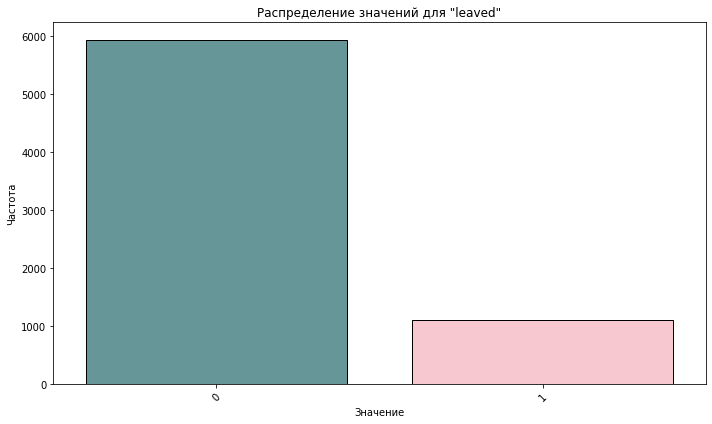

In [27]:
# График соотношения людей, отказавшихся от услуг, и пользователей услуг:

plt.figure(figsize=(10, 6))  
sns.countplot(data=full, x='leaved',
              palette=['cadetblue', 'pink'], ec='black',
              )
plt.title('Распределение значений для "leaved"')
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.tick_params(axis='x', rotation=45)  
plt.tight_layout() 
plt.show()

Вывод: Преобладает количество клиентов, продолжающих использовать услуги компании, а значит в целевом признаке заметен дисбаланс.

(На самом деле, было бы печально, если бы данные были сбалансированы, ведь это означало бы, что клиенты очень часто расторгают договор с компанией)

Ввиду того, что задача предполагает использование метрики ROC-AUC, которая не чувствительна к дисбалансу, с ним ничего делать не будем.

График больше для наглядности.

Построим графики, сопоставим с описательной статистикой, полученной ранее и сформируем выводы.


1) Графики по непрерывным количественным признакам: к ним можно отнести monthly_charges, total_charges. Построим в разрезе целевого признака

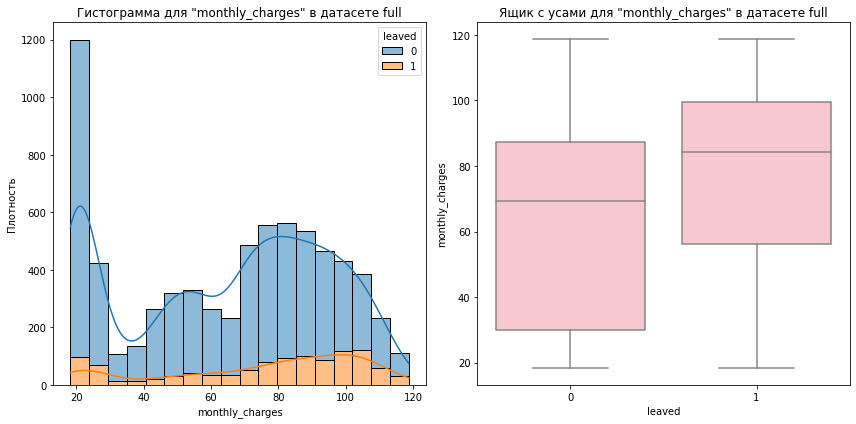

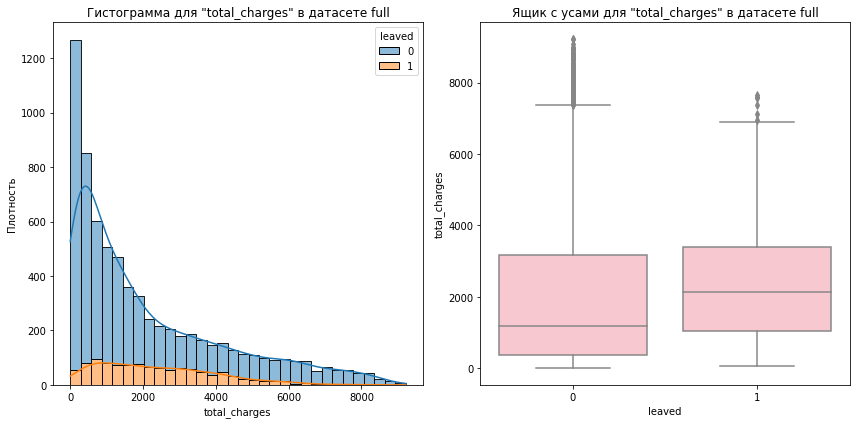

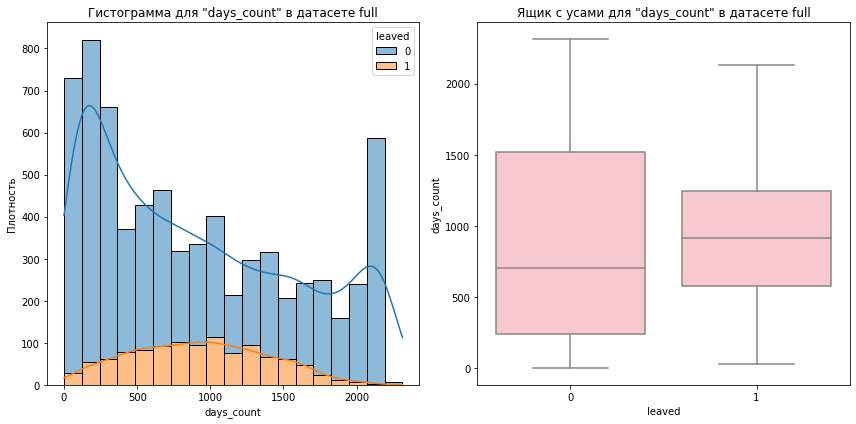

In [28]:
continuous_cols = ['monthly_charges', 'total_charges', 'days_count']

for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    axes[0].set_title(f'Гистограмма для "{col}" в датасете full')
    axes[1].set_title(f'Ящик с усами для "{col}" в датасете full')

    # Гистограмма распределения
    sns.histplot(
        data=full,
        kde =True, 
        x=col,      
        hue='leaved',  
        multiple="stack",  
        color='coolwarm',  
        ax=axes[0]  
    )
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Плотность')

    # Диаграмма "ящик с усами"
    sns.boxplot(
        y=col, 
        x='leaved',  
        data=full,  
        color='pink',  
        ax=axes[1] 
    )
    axes[1].set_xlabel('leaved')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

При рассмотрении описательной статистки уже было отмечено, что присутствует неравномерность данных.
Визуализация это подтвердила.

Общие закономерности: 
а) По месячным и общим расходам на услуги можно сделать вывод, что преобладающее количество клиентов старается минимизировать свои затраты. Клиентов, отказавшихся от услуг компании меньше, их данные распределены более равномерно

Месячные расходы (для оставшихся):

а) Наблюдается мультимодальность распределения, т.к. наблюдается 3 возвышения, а также имеется сдвиг влево

б) Выбросов на диаграмме ящик с усами не наблюдается, график указывает на ассиметричность данных.

Если, кстати сравнить с общими расходами - стоит отметить, что необходимо масштабирование.


Суммарные доходы ( для оставшихся) :

а) На гистограмме наблюдается распределение с обрывом слева.

б) на ящике с усами присутствуют выбросы, у клиентов, отказавшихся от услуг выбросов меньше.

Чем больше расходов на услуги, тем меньше клиентов.


___________________________________________________



***Понимаю, что дни это дискретный признак, но мне хотелось его тоже рассмотреть в разрезе целевого признака, если не примите это, уберу***

Вывод:

Наблюдаются мультимодальное распределение у клинетов, пользующихся услугами компании, и ассимметрия, значит, не так влияет количество дней пользования услугами.

У клиентов, отказавшихся от услуг, распределение ближе к нормульному.


2) Построим графики для дискретных признаков датасета в разрезе целевого признака, а также подсчитаем процентное соотношение. Так будет более наглядно и информативно:

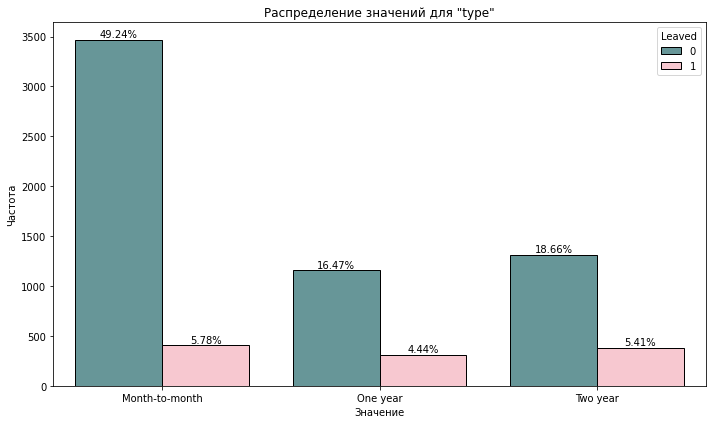

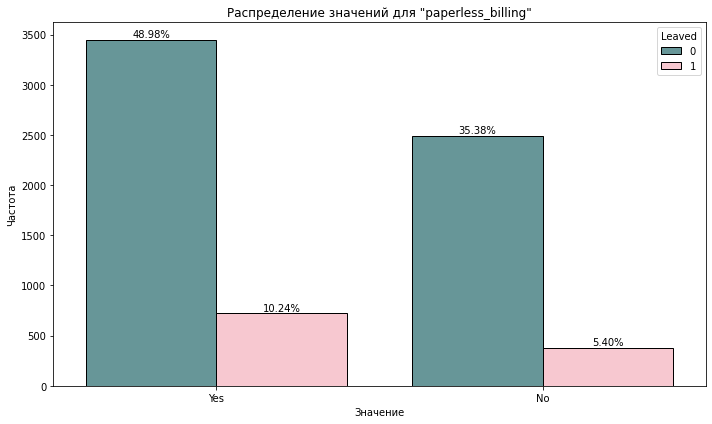

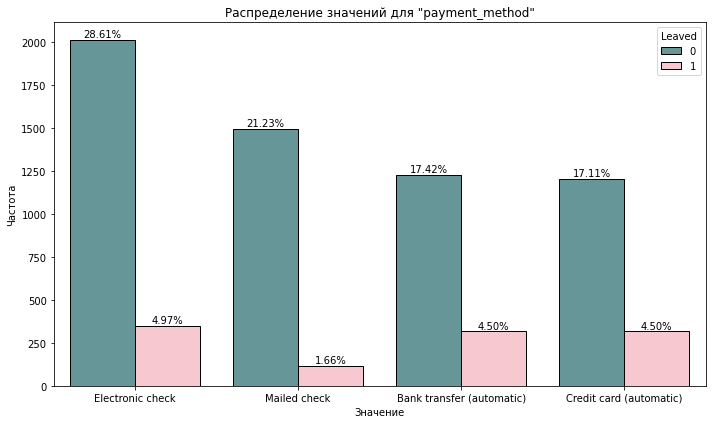

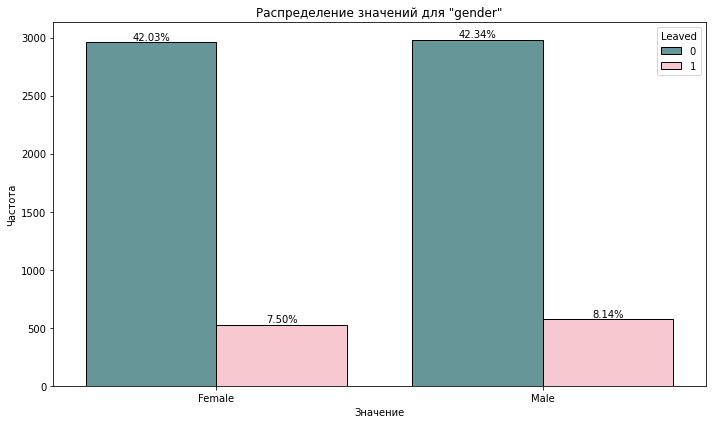

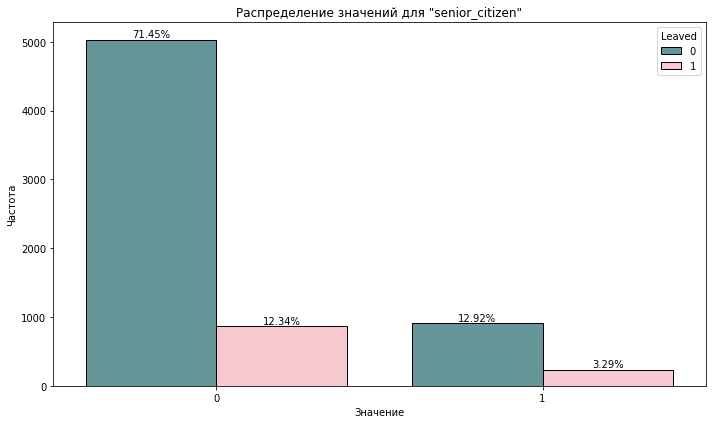

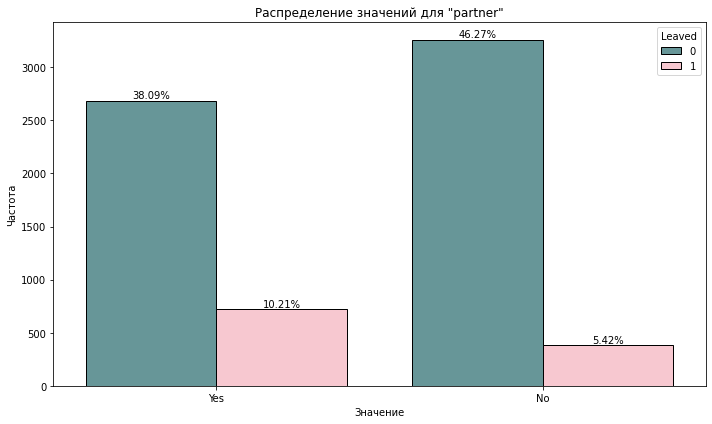

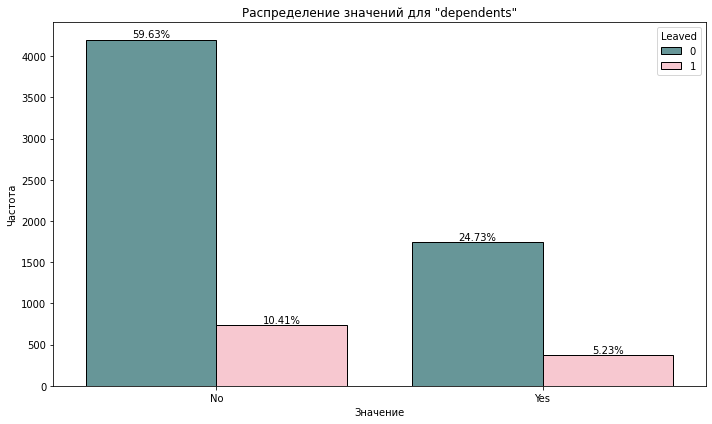

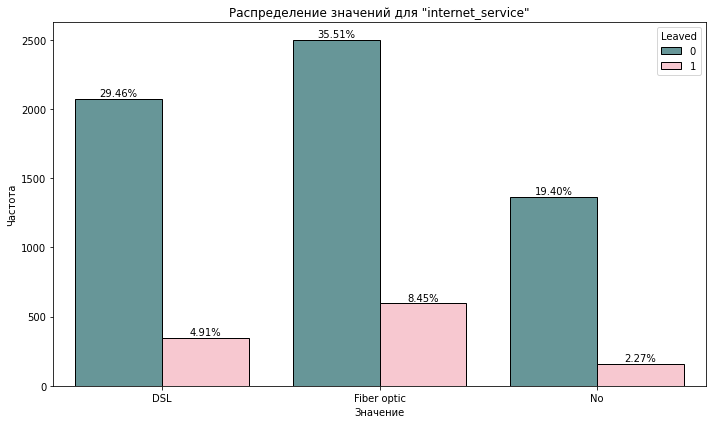

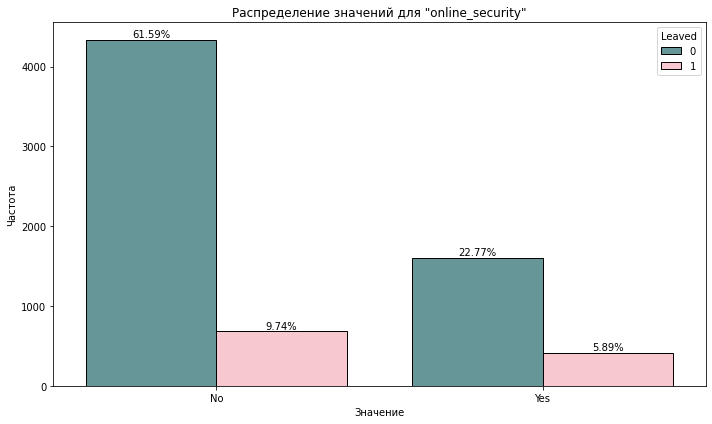

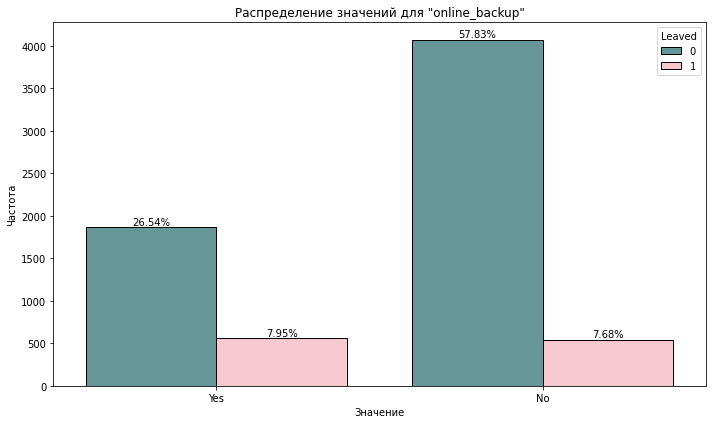

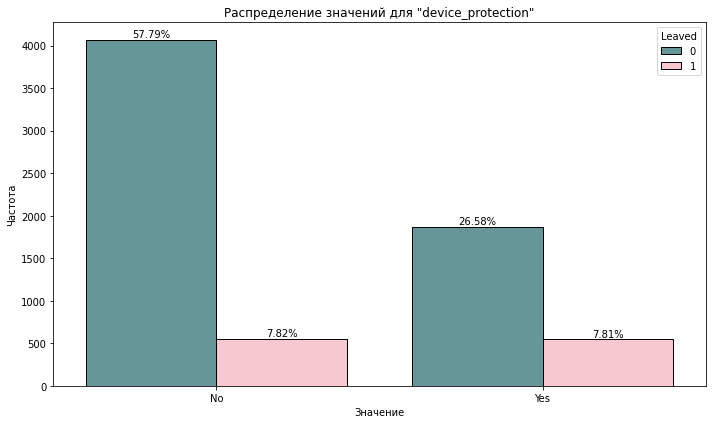

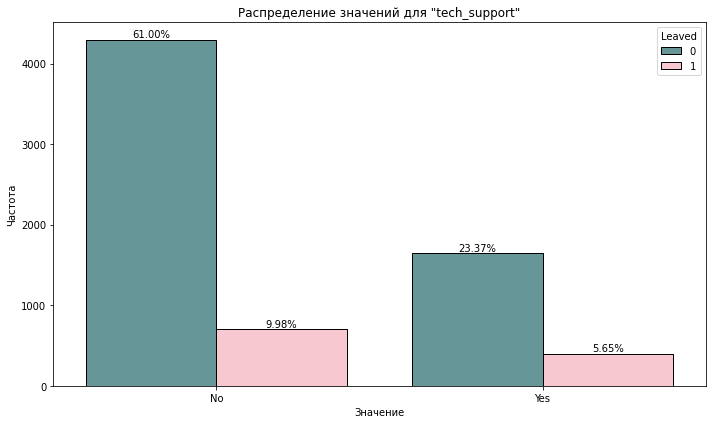

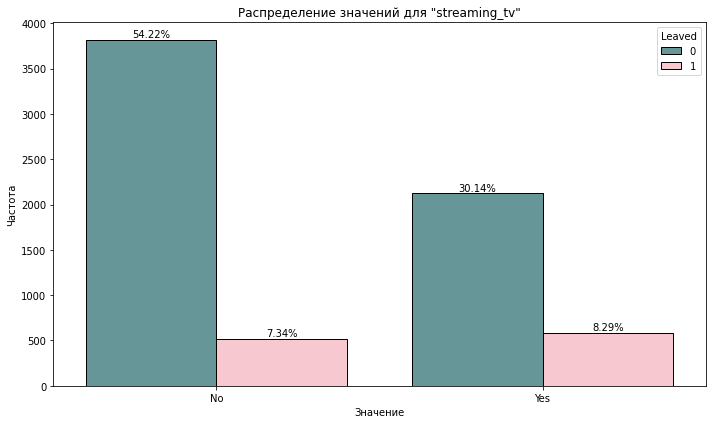

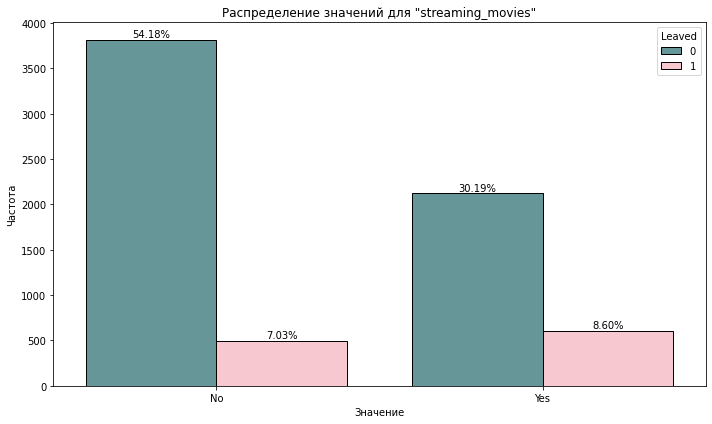

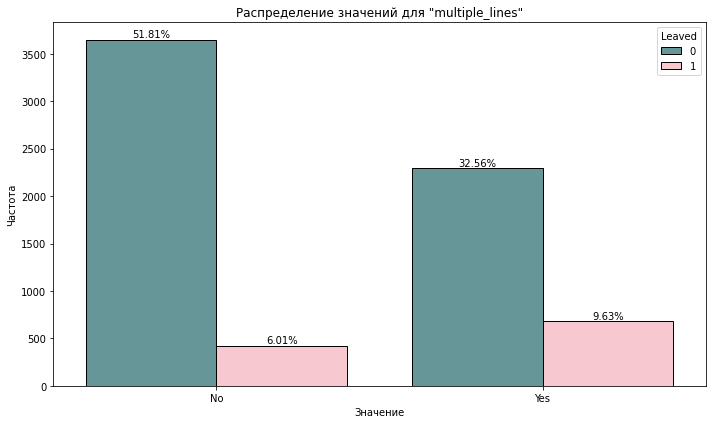

In [29]:
discrete_col = ['type', 'paperless_billing', 'payment_method', 
                'gender', 'senior_citizen', 'partner', 'dependents', 
                'internet_service', 'online_security', 'online_backup', 
                'device_protection', 'tech_support', 'streaming_tv', 
                'streaming_movies', 'multiple_lines']

for col in discrete_col:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=full, x=col, hue='leaved',
                       palette=['cadetblue', 'pink'], ec='black')
    plt.title(f'Распределение значений для "{col}"')
    plt.xlabel("Значение")
    plt.ylabel("Частота")

    # Шаг для расчета процентов
    total = len(full)
    
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2., height + 3,
                f'{height / total:.2%}',
                ha='center', va='bottom', fontsize=10)

    plt.legend(title='Leaved', loc='upper right')
    plt.tight_layout()
    plt.show()

Выводы по построенным графикам:

1) **'type'**

Преобладающее количество клиентов, пользующихся услугами компании, в качестве типа оплаты - выбирают ежемесячно.Это может быть обусловлено тем, что ежемесячные платежи могут казаться клиентам менее затратными, чем разовая оплата длительного периода, или могут сомневаться в том, что будет необходимость в подписке длительное время. Или покупка на длительный период не кажется клиентам выгодным приобретением, ввиду небольшой разницы в стоимости.

Однако, если оценивать клиентов, расторгнувших договор, то у них соотношение между типами оплат примерно равное. Можно предположить, что тип оплаты не являлся ключевым решением  - одна из версий.

2) **paperless_billing**

Преобладающее количество клиентов обеих категорий клиентов предпочитают/предпочитали получать электронный расчетный лист. Уже на данном этапе можно предположить, что возможно не нужно учитывать данный признак при обучении модели.

3) **payment_method**

Тип платежа имеет примерно одинаковое распределение, только у клиентов - оттока mailed check не был популярен.

4) **gender**

Соотношение пола примерно равное, что может говорить о том, что и мужчины, и женщины отказывались от услуг компании одинаково.

5) **senior_citizen**

Примерно 16% клиентов обеих категорий являются пенсионерами. Что является логичным, не многие пенсионеры пользуются технологиями, хоть сейчас и наблюдается тенденция к росту, но услуги клиента более актуальны для лиц молодого и среднего возраста.

6) **partner**

Если рассматривать суммарно обе категории клиентов, то распределение по признаку наличие партнера примерно равное. Однако, если смотреть в разрезе целевого признака, можно отметить, что клиенты, имеющие супруга или супругу, больше отказываются от услуг компании.

7) **dependents**

Количественно преобладают пользователи, не имеющие детей.

8) **internet_service**

Преобладает тип подключения оптоволоконный кабель, а также стоит отметить, что и отказалось от услуг больше клиентов, использующих данный тип подключения. Возможно, есть взаимосвязь с качеством соединения и типом подключения. Но точных выводов сделать не получится, так как часть данных отсутствует (заменена на Unk)

9) **online_security**

Преобладающее число клинетов не использует услугу блокировки опасных сайтов

10) **online_backup**

Преобладающее число клиентов обеих категорий не используют услугу облачного хранилища данных

11) **device_protection**

Преобладающее количество клиентов обеих категорий не используют услугу антивируса. А преобладающая часть клиентов из категории ушедних имела данную услугу в пакете. Можно предположить, что их могло не устроить качество.

12) **tech_support** 

Преобладающее количество клиентов обеих категорий не используют услугу выделенная линия технической поддержки. 

13) **streaming_tv**

Данной услугой пользуется примерно одинаковое количество клиентов.

14) **streaming_movies**

Также можно сделать вывод о примерно равном соотношении. Однако у большего количества пользователей, расторгнувших договор, эта услуга была. Возможно, клиентам мог не понравиться ассортимент фильмов или другие факторы.

15) **multiple_lines**

У чуть большего количества клиентов осуществляется подключение телефона к нескольким линиям  одновременно.


**Выводы по исследовательскому анализу**

Полученные данные по исследовательскому анализу помогли более подробно интерпертировать данные, полученные от описательной статистики в первых шагах задачи.

Графики строились в разрезе целевого признака, чтобы более точно постараться отследить причины оттока клиентов.

Были выявлены признаки, которые имеют примерно равное распределение, что может говорить о том, что они не дают большой вклад в причины оттока клиентов.

Что касается подключаемх услуг, т.к. у нас нет полных данных, точно определить вклад наличия тех или иных услуг сложно. А так, в целом люди скорее предпочтут не пользоваться большим количеством доп услуг, здесь уже можно найти пересечение с графиком общих и ежемесячных расходов, где было отмечено, что клиенты стараются минимизировать затраты.

В целевом признаке был обнаружен дисбаланс. Однако метрика, на основании которой будет оцениваться модель, не чувствительна к дисбалансу.


**Проведя исследование, можно составить примерный портрет пользователя услуг компании "Теледом"**

*Мужчина или женщина молодого или среднего возраста. Состоит в браке или свободен/на, без детей. Предпочитает ежемесячную оплату, у клиента преобладает подключение через оптоволоконный кабель, скорее не предпочитает доп.услуги, кроме стриминговых.*


## Построение матрицы корреляции

In [30]:
full = full.set_index('customer_id')

full.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   begin_date         7043 non-null   datetime64[ns]
 1   end_date           7043 non-null   object        
 2   type               7043 non-null   object        
 3   paperless_billing  7043 non-null   object        
 4   payment_method     7043 non-null   object        
 5   monthly_charges    7043 non-null   float64       
 6   total_charges      7043 non-null   float64       
 7   gender             7043 non-null   object        
 8   senior_citizen     7043 non-null   int64         
 9   partner            7043 non-null   object        
 10  dependents         7043 non-null   object        
 11  internet_service   7043 non-null   object        
 12  online_security    7043 non-null   object        
 13  online_backup      7043 non-null   object        
 14

In [31]:
# Удалим столбцы, которые могут бы неинформативны для матрицы и в дальнейших задачах:

full = full.drop(['begin_date', 'end_date'], axis=1)

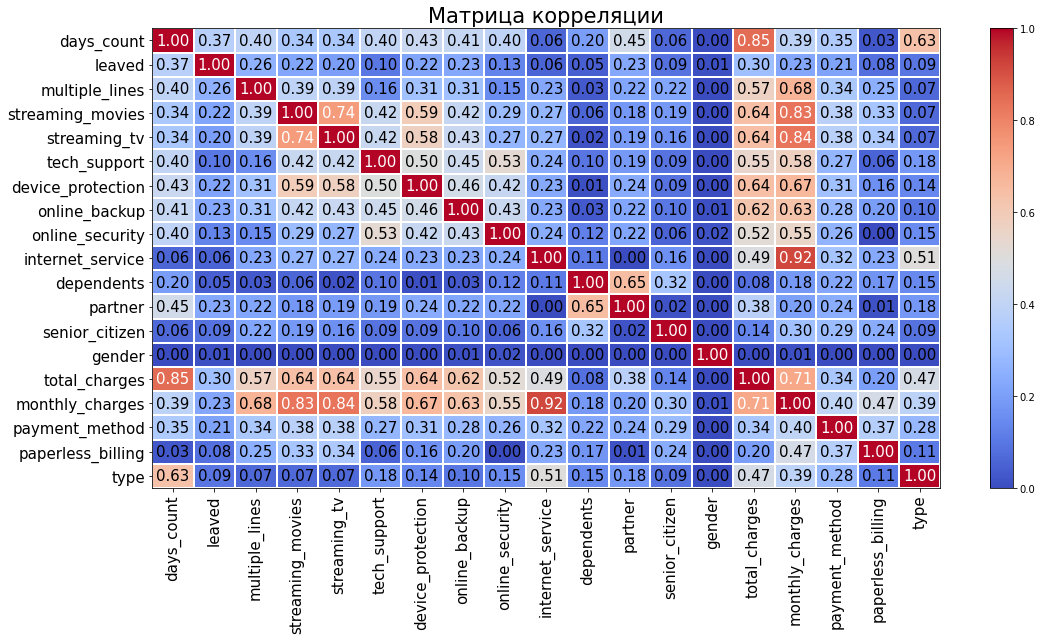

In [32]:
interval_cols = ['monthly_charges', 'total_charges', 'days_count']

corr_matrix = phik_matrix(full, interval_cols=interval_cols)


plot_correlation_matrix(
    corr_matrix.values,
    x_labels = corr_matrix.columns,
    y_labels = corr_matrix.index,
    vmin = 0, vmax = 1, color_map = 'coolwarm',
    title='Матрица корреляции',
    fontsize_factor=1.5,
    figsize=(16, 9)
)

Согласно матрице корреляции, имеется мультиколлинеарность  между признаками, отвечающими за дополнительные услуги. А также небольшая между признаки месячных и общих расходов.

Низкая корреляция между целевым признаком и признаком типа подключения, пола, статуса пенсионера, наличия супруги/супруга, детей.

Чтобы мультиколлинеарные данные не влияли на обучение модели, проведем следующие преобразования:


In [33]:
dlc = ['internet_service', 'online_security', 
       'online_backup', 'device_protection', 
       'tech_support', 'streaming_tv', 'streaming_movies']
full['dlc'] = full[dlc].apply(lambda row: (row == 'Yes').sum(), axis=1)
full = full.drop(dlc, axis=1)

In [34]:
full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               7043 non-null   object 
 1   paperless_billing  7043 non-null   object 
 2   payment_method     7043 non-null   object 
 3   monthly_charges    7043 non-null   float64
 4   total_charges      7043 non-null   float64
 5   gender             7043 non-null   object 
 6   senior_citizen     7043 non-null   int64  
 7   partner            7043 non-null   object 
 8   dependents         7043 non-null   object 
 9   multiple_lines     7043 non-null   object 
 10  leaved             7043 non-null   int64  
 11  days_count         7043 non-null   int64  
 12  dlc                7043 non-null   int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 770.3+ KB


Благодаря проделанным преобразованиям, удалось избавиться от мультиколлинеарности. Дальнейшую работу будет проводить на оптимизированном датасете.

## Подготовка данных. Обучение моделей машинного обучения

In [35]:
# Выделим целевой признак и проведем разделение выборки на тренировочную и тестовую. 
# Константы импортировали ранее, поэтому здесь они не фигурируют

X = full.drop(['leaved'], axis=1)
y = full['leaved']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = test_size, 
    random_state = RANDOM_STATE)
full.shape # проверяем корректность разделения

(7043, 13)

In [36]:
ohe_columns = [ 'type', 'paperless_billing', 'payment_method',
               'gender', 'senior_citizen', 'partner', 'dependents', 'multiple_lines']
num_columns = ['monthly_charges', 'total_charges', 'days_count', 'dlc']


In [37]:
# Cоздаём пайплайны для подготовки признаков 
ohe_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

ord_pipe = Pipeline([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Логистическая регрессия общий пайплайн
data_preprocessor_1 = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', MinMaxScaler(), num_columns)
    ],
    remainder='passthrough'
)

# Итоговый пайплайн логистическая  регрессия
pipe_final_1 = Pipeline([
    ('preprocessor', data_preprocessor_1),
    ('models', LogisticRegression(random_state=RANDOM_STATE))
])



# Дерево решений общий пайплайн
data_preprocessor_2 = ColumnTransformer(
    [
        ('ord', ord_pipe, ohe_columns)
    ],
    remainder='passthrough'
)

# Дерево решений итоговый пайплайн
pipe_final_2 = Pipeline([
    ('preprocessor', data_preprocessor_2),
    ('models', RandomForestClassifier(random_state=RANDOM_STATE))
])

In [38]:
param_distributions_1 = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()]
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__C': range(1, 10),
        'models__kernel': ['rbf', 'linear', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  

    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
] 

param_distributions_2 = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'models__max_features': range(2, 11)
    },
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [50, 100, 150],
        'models__max_features': ['auto', 'sqrt', 'log2']
    },
    {
        'models': [CatBoostClassifier(random_state=RANDOM_STATE)],
        'models__iterations': range(100, 3000, 100),
        'models__learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.3, 0.5],
        'models__depth': range(2, 8, 1)
    }
] 

In [39]:
randomized_search_1 = RandomizedSearchCV(
    pipe_final_1, 
    param_distributions_1, 
    scoring={'roc_auc': 'roc_auc', 'accuracy': 'accuracy'},  # Используем дополнительную метрику
    refit='roc_auc',  
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search_1.fit(X_train, y_train)

print('Лучшая модель: \n', randomized_search_1.best_estimator_)
print('Значение roc-auc',randomized_search_1.best_score_)
print('Значение accuracy:', randomized_search_1.cv_results_['mean_test_accuracy'][randomized_search_1.best_index_])

Лучшая модель: 
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['type', 'paperless_billing',
                                                   'payment_method', 'gender',
                                                   'senior_citizen', 'partner',
                                                   'dependents',
                                                   'multiple_lines']),
                                                 ('num', StandardScaler(),
  

Данные значения далее будем сравнивать со значениями, полученными на кросс-валидации

In [40]:
# Кросс-валидация

randomized_search_2 = RandomizedSearchCV(
    pipe_final_2, 
    param_distributions_2, 
    scoring={'roc_auc': 'roc_auc', 'accuracy': 'accuracy'},  # Используем дополнительную метрику
    refit='roc_auc',  
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search_2.fit(X_train, y_train)

print('Лучшая модель: \n', randomized_search_2.best_estimator_)
print('Значение roc-auc',randomized_search_2.best_score_)
print('Значение accuracy:', randomized_search_2.cv_results_['mean_test_accuracy'][randomized_search_2.best_index_])

0:	learn: 0.6659882	total: 48.7ms	remaining: 19.4s
1:	learn: 0.6408898	total: 50.7ms	remaining: 10.1s
2:	learn: 0.6212948	total: 52.3ms	remaining: 6.92s
3:	learn: 0.6019787	total: 53.7ms	remaining: 5.31s
4:	learn: 0.5840605	total: 55.3ms	remaining: 4.37s
5:	learn: 0.5667230	total: 57.1ms	remaining: 3.75s
6:	learn: 0.5489376	total: 58.8ms	remaining: 3.3s
7:	learn: 0.5340256	total: 60.5ms	remaining: 2.96s
8:	learn: 0.5180895	total: 62.2ms	remaining: 2.7s
9:	learn: 0.5055236	total: 63.9ms	remaining: 2.49s
10:	learn: 0.4928130	total: 65.7ms	remaining: 2.32s
11:	learn: 0.4796119	total: 67.4ms	remaining: 2.18s
12:	learn: 0.4689594	total: 69ms	remaining: 2.06s
13:	learn: 0.4576706	total: 70.7ms	remaining: 1.95s
14:	learn: 0.4491611	total: 72.4ms	remaining: 1.86s
15:	learn: 0.4408540	total: 74.1ms	remaining: 1.78s
16:	learn: 0.4329854	total: 75.7ms	remaining: 1.7s
17:	learn: 0.4252779	total: 77.2ms	remaining: 1.64s
18:	learn: 0.4176231	total: 78.8ms	remaining: 1.58s
19:	learn: 0.4114182	total:

Лучшая метрика ROC-AUC и дополнительмая метрика Accuracy получились при использовании модели градиентного бустинга. 
Модель не переобучена, т.к. нет запределльно высоких значений метрики, и результат соответствует ТЗ : больше или равно 0.85

Именно эту модель мы будем проверять на тестовых данных.


## Предсказание выбранной модели на тестовых данных. Общие выводы.


In [41]:
y_pred = randomized_search_2.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)

print(f'Значение roc-auc на тестовой выборке: {roc_auc}')

Значение roc-auc на тестовой выборке: 0.9379638803819131


### Построение кривой

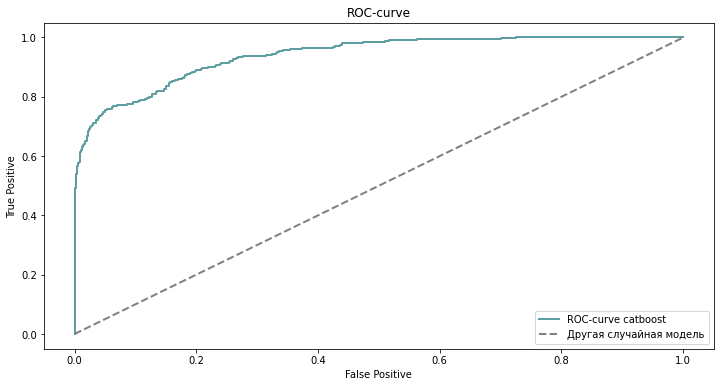

In [42]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color='cadetblue', lw=2, label=f'ROC-curve catboost')
plt.plot([0, 1], [0, 1], color='gray', lw=2, label='Другая случайная модель', linestyle='--')
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-curve')
plt.legend(loc="lower right")
plt.show()

### Построение матрицы ошибок

In [43]:
full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               7043 non-null   object 
 1   paperless_billing  7043 non-null   object 
 2   payment_method     7043 non-null   object 
 3   monthly_charges    7043 non-null   float64
 4   total_charges      7043 non-null   float64
 5   gender             7043 non-null   object 
 6   senior_citizen     7043 non-null   int64  
 7   partner            7043 non-null   object 
 8   dependents         7043 non-null   object 
 9   multiple_lines     7043 non-null   object 
 10  leaved             7043 non-null   int64  
 11  days_count         7043 non-null   int64  
 12  dlc                7043 non-null   int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 1.0+ MB


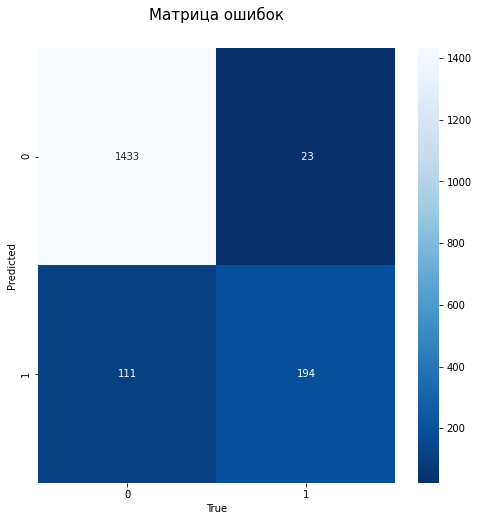

In [44]:
from sklearn.metrics import confusion_matrix
y_pred_class = (y_pred >= 0.5).astype(int)

plt.figure(figsize=(8, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_class), annot=True, fmt='3.0f', cmap='Blues_r')
plt.title('Матрица ошибок', y=1.05, size=15)
plt.xlabel('True')
plt.ylabel('Predicted')
plt.show()


Матрица ошибок позволяет сделать следующие выводы:

- TN - True Negative — 1438 раз модель правильно предсказала класс 0 (что клиент останется).

- FP - False Positive — 18 раз модель ошибочно предсказала 1 (что будет отток), хотя на самом деле был 0.

- FN - False Negative — 116 раз модель ошибочно предсказала 0, хотя на самом деле был 1.

- TP - True Positive — 189 раз модель правильно предсказала класс 1.

Модель хорошо предсказывает класс 0, но часто пропускает 1 (отток клиентов).

In [ ]:
!pip install -q shap

import shap

 99%|===================| 5253/5282 [02:15<00:00]        

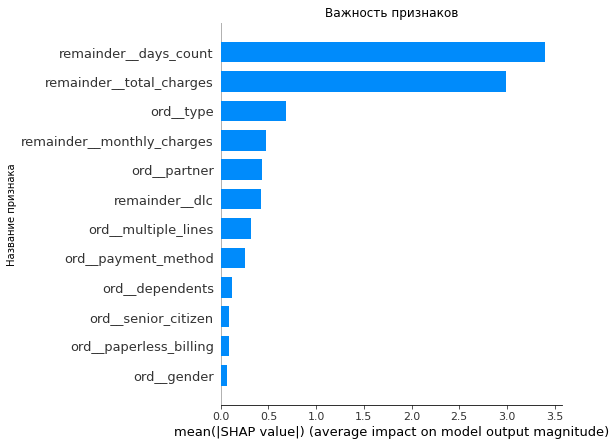

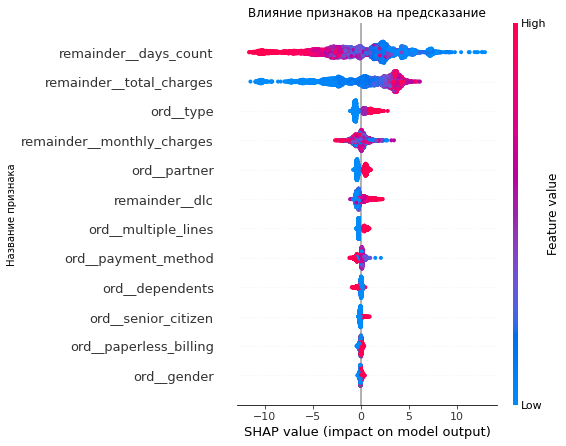

In [48]:
X_train_processed = best_model.named_steps['preprocessor'].transform(X_train)
feature_names = best_model['preprocessor'].get_feature_names_out()
data = pd.DataFrame(X_train_processed,columns=feature_names)

explainer = shap.TreeExplainer(best_model.named_steps['models'], data)
shap_values = explainer.shap_values(data)

plt.ylabel('Признаки')
plt.title('Важность признаков')
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, plot_type="bar", max_display=15)


plt.ylabel('Признаки')
plt.title('Влияние на предсказание')
shap.summary_plot(shap_values, X_train_processed, feature_names=feature_names, max_display=15)

**Вывод по анализу важности признаков:**


Признаки с положительными значениями SHAP повышают вероятность того, что клиент уйдет (класс 1), а признаки с отрицательными значениями - понижают (класс 0).


Данный анализ подтвердил корректность выводов, сделанных на этапе исследовательского анализа:

- не оказывает влияния на предсказание модели: пол, способ получения расчетного листа, наличие детей.

- признаки близкие к нулю, не оказывают значительного влияния.

Выделим Топ-3 из признаков, которые важны модели для предсказания оттока:

- Количество дней договора

- Общие расходы(затраты)

- Тип оплаты


Если мы хотим предложить бизнесу дополнительные рекомендации по снижению оттока клиентов, одним из ключевых направлений должна стать оптимизация ценовой политики, как было отмечено в финальном выводе.

Безусловно, полностью минимизировать стоимость услуг невозможно, так как бизнес должен оставаться рентабельным.

Однако проведение периодических акций ъ может стать эффективным инструментом для удержания клиентов. 

Кроме того, хоть признак того пенсионер клиент, или нет, не оказывает значительного влияния на прогноз модели, важно не упускать из виду эту категорию пользователей. Пожилые клиенты, получив качественный сервис и ощущая реальную пользу от услуг, могут стать одними из самых лояльных клиентов. Поэтому рекомендуется уделять особое внимание качеству оказываемых услуг, персонализированному подходу и разработке предложений, которые будут не только облегчать их повседневную жизнь, но и вызывать чувство доверия и удовлетворения.

### Общий вывод: 

В результате проделанной работы, было обработано 4 датасета: contract_new (информация о договоре), personal_new (информация о клиентах), internet_new (информация об интернет-услугах) и phone_new (информация об услугах телефонии).

* Данные датасеты имеют 7043, 7043, 6361, 5517 строк соответственно.

* В соответствии с правилами хорошего стиля были отреакдтированы наименования столбцов, а также в датасете присутствовали неправильные типы данных, поэтому на этапе предобработки изменили типы данных на верные:

    - в датасете contract_new были обнаружены столбцы с неверным типом данных - total_charges, в процессе работы тип данных был исправлен, что привело к тому, что были выявлены пропущенные значения в столбце (Nan), которые было принято заменить нулевым значением, т.к. анализ показал. что 11 записей с таким значением объединяет то, что начало использования услуг соответствует дате выгрузки данных, т.е. по пользователям данные еще не накопились;



* В результате проведенного исследовательского анализа данных были обработаны численные и категориальные признаки. Изучили описательную статистику численных и категориальных признаков, чтобы изучить их распределение, наличие выбросов. Для каждого из признаков были построены графики (гистограммы, ящик с усами, диаграммы)

* Все датасеты объединяет наличие стобца - customer_id, для дальнейшего анализа было принято решение объединить датасеты по данному столбцу.


В процессе объединения датасетов получилось следующее:

- объединение прошло успешно
 
- так как в последних двух датасетах количество записей было меньше, чем в contract_new и personal_new, в объединенном датасете в части столбцов internet_new и phone_new можно отметить наличие пропущенных значений, которые мы впоследствии заполнили - пропуски были заполнены значением 'Unk' (Unknown), удалять их не будем, т.к. это данные которые в дальнейшем пригодятся для решения задачи.

- а также в датасет были добавлены новые признаки:

    * столбец - leaved - данный столбец также будет являлся целевым признаком, так как мы изучаем отток клиентов и нам необходимо классифицировать их
    * а также столбец с количеством дней пользования услугами.
    
    
При построении графиков у некоторых показателей были выявлены выбросы (например, total_charge). Но данные не будем удалять, т.к. цель - обучить модель машинного обучения.

Преобладает количество клиентов, продолжающих использовать услуги компании, а значит в целевом признаке заметен дисбаланс.

(На самом деле, было бы печально, если бы данные были сбалансированы, ведь это означало бы, что клиенты очень часто расторгают договор с компанией)

Ввиду того, что задача предполагает использование метрики ROC-AUC, которая не чувствительна к дисбалансу, дисбаланс не убирали.

Построили графики в разрезе целевого признака, что позволило отследить следующие параметры:


Общие закономерности: а) По месячным и общим расходам на услуги можно сделать вывод, что преобладающее количество клиентов старается минимизировать свои затраты. Клиентов, отказавшихся от услуг компании меньше, их данные распределены более равномерно

Месячные расходы (для оставшихся):

а) Наблюдается мультимодальность распределения, т.к. наблюдается 3 возвышения, а также имеется сдвиг влево

б) Выбросов на диаграмме ящик с усами не наблюдается, график указывает на ассиметричность данных.

Если, кстати сравнить с общими расходами - стоит отметить, что необходимо масштабирование.

Суммарные доходы ( для оставшихся) :

а) На гистограмме наблюдается распределение с обрывом слева.

б) на ящике с усами присутствуют выбросы, у клиентов, отказавшихся от услуг выбросов меньше.

Чем больше расходов на услуги, тем меньше клиентов.

1) 'type'

Преобладающее количество клиентов, пользующихся услугами компании, в качестве типа оплаты - выбирают ежемесячно.Это может быть обусловлено тем, что ежемесячные платежи могут казаться клиентам менее затратными, чем разовая оплата длительного периода, или могут сомневаться в том, что будет необходимость в подписке длительное время. Или покупка на длительный период не кажется клиентам выгодным приобретением, ввиду небольшой разницы в стоимости.

Однако, если оценивать клиентов, расторгнувших договор, то у них соотношение между типами оплат примерно равное. Можно предположить, что тип оплаты не являлся ключевым решением - одна из версий.

2) paperless_billing

Преобладающее количество клиентов обеих категорий клиентов предпочитают/предпочитали получать электронный расчетный лист. Уже на данном этапе можно предположить, что возможно не нужно учитывать данный признак при обучении модели.

3) payment_method

Тип платежа имеет примерно одинаковое распределение, только у клиентов - оттока mailed check не был популярен.

4) gender

Соотношение пола примерно равное, что может говорить о том, что и мужчины, и женщины отказывались от услуг компании одинаково.

5) senior_citizen

Примерно 16% клиентов обеих категорий являются пенсионерами. Что является логичным, не многие пенсионеры пользуются технологиями, хоть сейчас и наблюдается тенденция к росту, но услуги клиента более актуальны для лиц молодого и среднего возраста.

6) partner

Если рассматривать суммарно обе категории клиентов, то распределение по признаку наличие партнера примерно равное. Однако, если смотреть в разрезе целевого признака, можно отметить, что клиенты, имеющие супруга или супругу, больше отказываются от услуг компании.

7) dependents

Количественно преобладают пользователи, не имеющие детей.

8) internet_service

Преобладает тип подключения оптоволоконный кабель, а также стоит отметить, что и отказалось от услуг больше клиентов, использующих данный тип подключения. Возможно, есть взаимосвязь с качеством соединения и типом подключения. Но точных выводов сделать не получится, так как часть данных отсутствует (заменена на Unk)

9) online_security

Преобладающее число клинетов не использует услугу блокировки опасных сайтов

10) online_backup

Преобладающее число клиентов обеих категорий не используют услугу облачного хранилища данных

11) device_protection

Преобладающее количество клиентов обеих категорий не используют услугу антивируса. А преобладающая часть клиентов из категории ушедних имела данную услугу в пакете. Можно предположить, что их могло не устроить качество.

12) tech_support

Преобладающее количество клиентов обеих категорий не используют услугу выделенная линия технической поддержки.

13) streaming_tv

Данной услугой пользуется примерно одинаковое количество клиентов.

14) streaming_movies

Также можно сделать вывод о примерно равном соотношении. Однако у большего количества пользователей, расторгнувших договор, эта услуга была. Возможно, клиентам мог не понравиться ассортимент фильмов или другие факторы.

15) multiple_lines

У чуть большего количества клиентов осуществляется подключение телефона к нескольким линиям одновременно.

Выводы по исследовательскому анализу

Полученные данные по исследовательскому анализу помогли более подробно интерпертировать данные, полученные от описательной статистики в первых шагах задачи.

Графики строились в разрезе целевого признака, чтобы более точно постараться отследить причины оттока клиентов.

Были выявлены признаки, которые имеют примерно равное распределение, что может говорить о том, что они не дают большой вклад в причины оттока клиентов.

Что касается подключаемх услуг, т.к. у нас нет полных данных, точно определить вклад наличия тех или иных услуг сложно. А так, в целом люди скорее предпочтут не пользоваться большим количеством доп услуг, здесь уже можно найти пересечение с графиком общих и ежемесячных расходов, где было отмечено, что клиенты стараются минимизировать затраты.

В целевом признаке был обнаружен дисбаланс. Однако метрика, на основании которой будет оцениваться модель, не чувствительна к дисбалансу.

Проведя исследование, можно составить примерный портрет пользователя услуг компании "Теледом"

*Мужчина или женщина молодого или среднего возраста. Состоит в браке или свободен/на, без детей. Предпочитает ежемесячную оплату, у клиента преобладает подключение через оптоволоконный кабель, скорее не предпочитает доп.услуги, кроме стриминговых.*


* Также одним из этапов работы было построение матрицы корреляции:

Согласно матрице корреляции, имеется мультиколлинеарность между признаками, отвечающими за дополнительные услуги. А также небольшая между признаки месячных и общих расходов.

Низкая корреляция между целевым признаком и признаком типа подключения, пола, статуса пенсионера, наличия супруги/супруга, детей.

Чтобы мультиколлинеарные данные не влияли на обучение модели, провели преобразования, заключающиеся в объединении столбцов по признаку "дополнения".



Обучили две модели с подбором гипперпараметров - Логистическую регрессию и CatBoostClassifier.

Логистическая регрессия показала лучший результат 0,77
Градиентный бустинг лучший результат: 0,917, acc = 0,93

Лучшая метрика ROC-AUC и дополнительмая метрика Accuracy получились при использовании модели градиентного бустинга. Модель не переобучена, т.к. нет запределльно высоких значений метрики. Результат оценили после непосредственной проверки


Именно эту модель мы будем провеяли на тестовых данных и получили результат  0,938
Что полностью удовлетворяет ТЗ. (более или равно 0,85)

А также посмтроили матрицу ошибок:
Матрица ошибок позволяет сделать следующие выводы:

TN - True Negative — 1438 раз модель правильно предсказала класс 0 (что клиент останется).

FP - False Positive — 18 раз модель ошибочно предсказала 1 (что будет отток), хотя на самом деле был 0.

FN - False Negative — 116 раз модель ошибочно предсказала 0, хотя на самом деле был 1.

TP - True Positive — 189 раз модель правильно предсказала класс 1.

Модель хорошо предсказывает класс 0, но часто пропускает 1 (отток клиентов).





Из рекомендаций хотелось бы выделить, что раз пол, наличие семьи и идетей не играет большой роли, сделать упор на другие показатели.

- Например, если компании выгоднее продавать доп услуги, то нужно поработать над качеством этих доп услуг: например, для стриминговых сервисов постоянно актуализировать фильмы, делать акции

- Пересмотреть ценовую политику, если цена слишком высока, или рассмотреть добавление акций, программ лояльности, что, например, может привлечь пожилых людей

- Анализировать поведение клиентов, а также проводить мониторинг работы сотрудников, которые непосредственно взаимодействуют с клиентами, т..к от их взаимодействия тоже многое зависит: впечатление, настрой клиента.